# Taller Análisis Exploratorio de Datos

Sara Pineda Valencia

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [20]:
from google.colab import files

uploaded = files.upload()

Saving crx.data to crx (1).data


In [21]:
import pandas as pd

df = pd.read_csv(
    "crx.data",
    header=None,
    na_values="?",
    names=['A1', 'A2', 'A3', 'A4', 'A5',
           'A6', 'A7', 'A8', 'A9', 'A10',
           'A11', 'A12', 'A13', 'A14', 'A15']
)

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 690 entries, b to b
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    float64
 1   A2      690 non-null    float64
 2   A3      684 non-null    object 
 3   A4      684 non-null    object 
 4   A5      681 non-null    object 
 5   A6      681 non-null    object 
 6   A7      690 non-null    float64
 7   A8      690 non-null    object 
 8   A9      690 non-null    object 
 9   A10     690 non-null    int64  
 10  A11     690 non-null    object 
 11  A12     690 non-null    object 
 12  A13     677 non-null    float64
 13  A14     690 non-null    int64  
 14  A15     690 non-null    object 
dtypes: float64(4), int64(2), object(9)
memory usage: 102.4+ KB


- ¿Cuántas filas y columnas tiene el dataframe?
  R// El dataframe tiene 16 columnas (contando la columna index) y 690 filas
      "Index: 690 entries, b to b
      Data columns (total 15 columns)"

- ¿De qué tipo de dato es cada columna?
  R// Las columnas A3, A4, A5, A6, A8, A9, A11, A12, A15 son de tipo objetc(9), las columnas A1, A2, A7, A13 son de tipo float64(4) y las columnas A10, A14 son de tipo int64(2)

- ¿Las variables están en el tipo de dato correcto para su contenido?
  Las variables de cada columna mostradas en el cuadro anterior coinciden con el tipo de dato que señala el resultado de la funcion .info()

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [23]:
df.describe(include='object')

,A3,A4,A5,A6,A8,A9,A11,A12,A15
count,684,684,681,681,690,690,690,690,690
unique,3,3,14,9,2,2,2,3,2
top,u,g,c,v,t,f,f,g,-
freq,519,519,137,399,361,395,374,625,383


In [24]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "A3" tiene las siguientes categorías: 
 ['u' 'y' nan 'l'] 

La columna "A4" tiene las siguientes categorías: 
 ['g' 'p' nan 'gg'] 

La columna "A5" tiene las siguientes categorías: 
 ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j' nan] 

La columna "A6" tiene las siguientes categorías: 
 ['v' 'h' 'bb' 'ff' 'j' 'z' nan 'o' 'dd' 'n'] 

La columna "A8" tiene las siguientes categorías: 
 ['t' 'f'] 

La columna "A9" tiene las siguientes categorías: 
 ['t' 'f'] 

La columna "A11" tiene las siguientes categorías: 
 ['f' 't'] 

La columna "A12" tiene las siguientes categorías: 
 ['g' 's' 'p'] 

La columna "A15" tiene las siguientes categorías: 
 ['+' '-'] 



- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
  Según lo mostrado en las funciones y en lo dicho en la documentación inicial no hay valores imposibles o fuera del rango

- ¿Hay variables que no varían?
  R// No, pues todas las variables tienen más de un valor único

- Qué variables cualitativas tienen muchos valores únicos (alta cardinalidad)?
  R// Las variables con mayor cantidad de valores únicos son: A5: 14 valores único y A6: 9 valores únicos, estas son las que presentan mayor cardinalidad

- ¿Hay claves primarias o identificadores únicos?
  R// No se observa un identificador único en estas variables.La cantidad de valores únicos de cada variable es muy inferior al número de registros (690).

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [25]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

,0
A13,1.884058
A1,1.739130
A6,1.304348
A5,1.304348
A4,0.869565
A3,0.869565
A2,0.000000
A7,0.000000
A8,0.000000
A10,0.000000


In [26]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


- ¿Qué variables tienen valores nulos? ¿En qué proporción?
  R// Las variables que presentan valores nulos son: A13 1.88%, A1 1.74%, A6 1.30%, A5 1.30%, A4 0.87%, A3 0.87%. Las demás variables (A2, A7, A8, A9, A10, A11, A12, A14 y A15) presentan 0 % de valores nulos. En general, el porcentaje de valores faltantes es bajo, ya que ninguna variable supera el 2 % de nulos.

- ¿Hay registros duplicados?
  R// No se encuentran registros duplicados

- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?
  R// Con los datos mostrados, no se evidencia un problema de formato relacionado con fechas, monedas o formatos numéricos.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

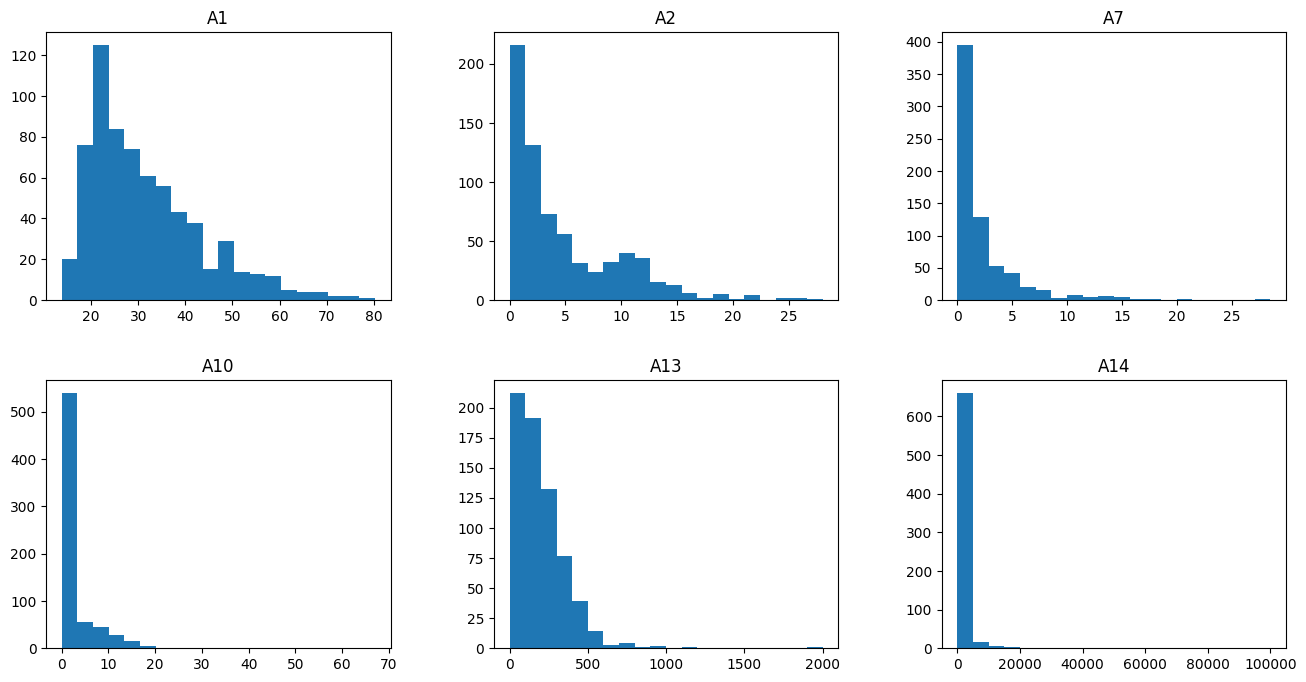

In [27]:
df.hist(figsize=(16, 8), bins=20, layout=(2,3), grid=False, sharex=False, sharey=False);

In [28]:
num_vars = df.select_dtypes(include=["number"]).columns
print('Variables numéricas: ', num_vars)

Variables numéricas:  Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='object')


In [29]:
# Verificar supuesto de normalidad con prueba de Kolmogorov-Smirnov

from scipy.stats import kstest

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para A1:
  Valor p: nan
  A1 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A2:
  Valor p: 1.3014031904956561e-18
  A2 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A7:
  Valor p: 1.7508115416086583e-39
  A7 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A10:
  Valor p: 1.0376830545783983e-59
  A10 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A13:
  Valor p: nan
  A13 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A14:
  Valor p: 2.9497270652247685e-112
  A14 no parece ser normal (se rechaza la hipótesis nula)



A traves de lo observado en las gráficas y los resultados arrojados al usar la prueba de Kolmogorov-Smirnov ninguna de esas variables es normal

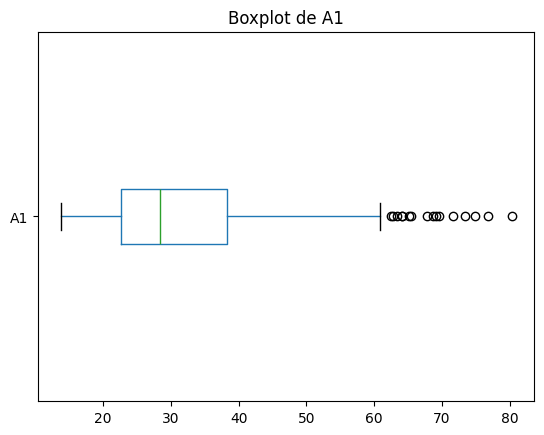

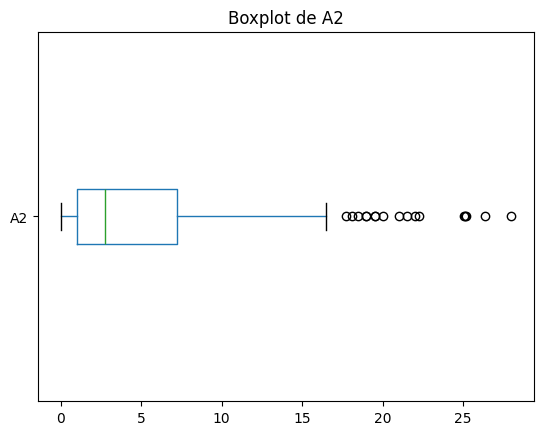

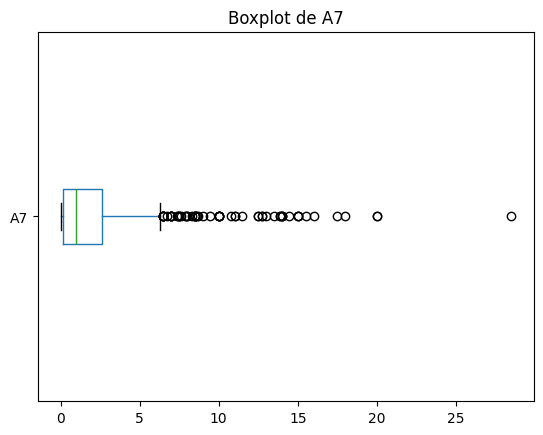

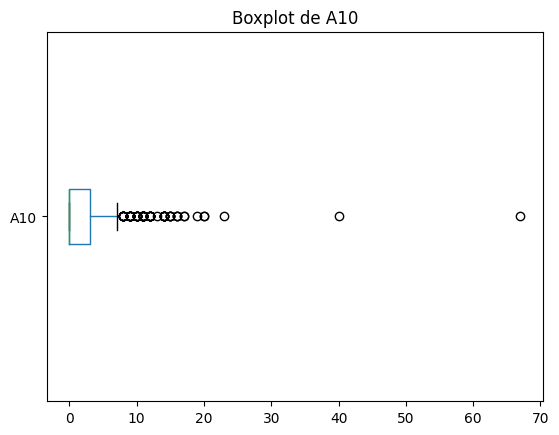

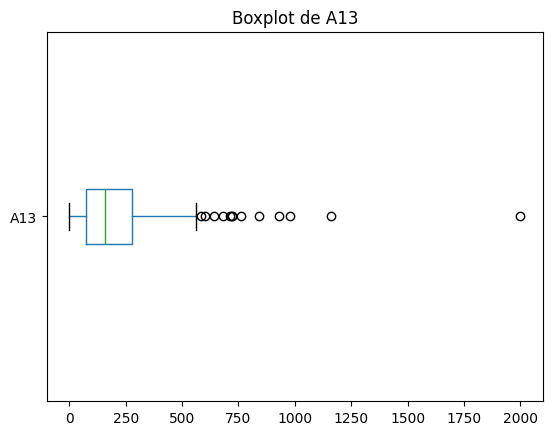

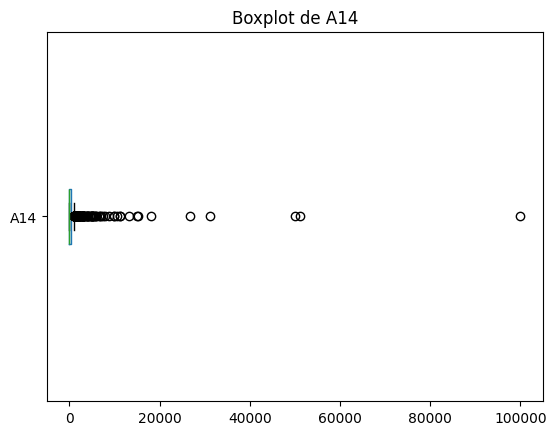

In [30]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

por lo visto en los diagramas de cajas se puede decir que todas las variables tienen outliers, pero los casos más críticos son los outliers de las variables A10 y A14

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [31]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable A3 es: 
 A3
u    519
y    163
l      2
Name: count, dtype: int64 

El conteo de la variable A4 es: 
 A4
g     519
p     163
gg      2
Name: count, dtype: int64 

El conteo de la variable A5 es: 
 A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64 

El conteo de la variable A6 es: 
 A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64 

El conteo de la variable A8 es: 
 A8
t    361
f    329
Name: count, dtype: int64 

El conteo de la variable A9 es: 
 A9
f    395
t    295
Name: count, dtype: int64 

El conteo de la variable A11 es: 
 A11
f    374
t    316
Name: count, dtype: int64 

El conteo de la variable A12 es: 
 A12
g    625
s     57
p      8
Name: count, dtype: int64 

El conteo de la variable A15 es: 
 A15
-    383
+    307
Name: count, dtype: int64 



- ¿Cómo se comportan las variables categóricas?
  R// Las variables presentan pocas categorías y, en la mayoría de los casos, se podría decir que hay categorías atípicas. Esto se puede observar directamente en los conteos enviados. Por ejemplo, en A3, la categoría "u" tiene 519 registros, mientras que "l" solo 2, y así con varias categórias más. Por otro lado, variables como A8 (t: 361, f: 329) y A15 (-: 383, +: 307) presentan una distribución más equilibrada.

- ¿Existen variables de alta cardinalidad?
  R// Esto se puede observar contando el número de categorías diferentes de cada variable. La variable con mayor cantidad de categorías es A5, que tiene 14 categorías, pero no necesariamente es de alta cardinalidad, pues en proporción con la cantidad de registros(690) sigue siendo un número relativamente bajo. Le sigue A6, con 9 categorías. Las demás variables tienen entre 2 y 4 categorías.

- ¿Existen categorías atípicas?
  R// Sí, existen algunas categorías con una frecuencia muy baja, que pueden considerarse atípicas. Por ejemplo, en A3, la categoría "l" aparece únicamente 2 veces; en A4, "gg" aparece también 2 veces. En A5, la categoría "r" tiene solo 3 registros, y en A6, "o" aparece únicamente 2 veces. En A12, la categoría "p" tiene 8 registros.

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


<Figure size 640x480 with 0 Axes>

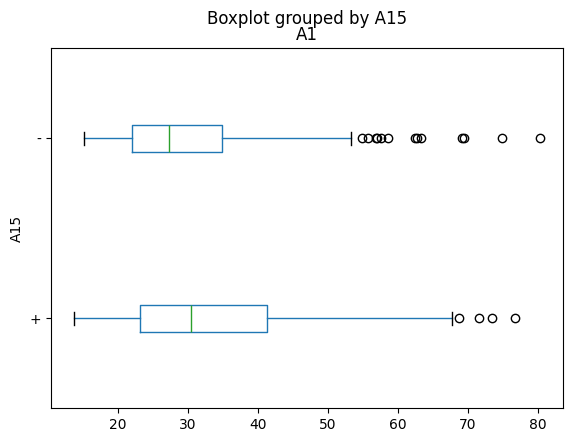

<Figure size 640x480 with 0 Axes>

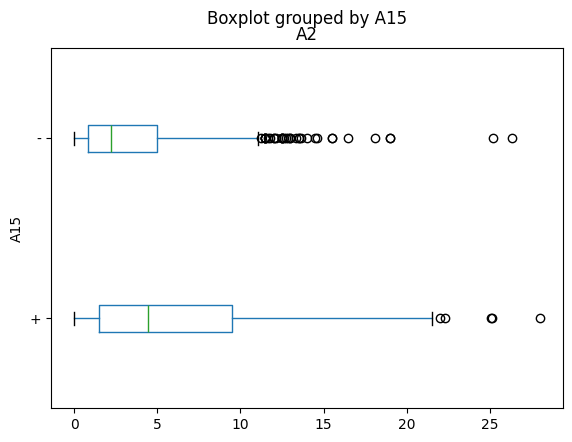

<Figure size 640x480 with 0 Axes>

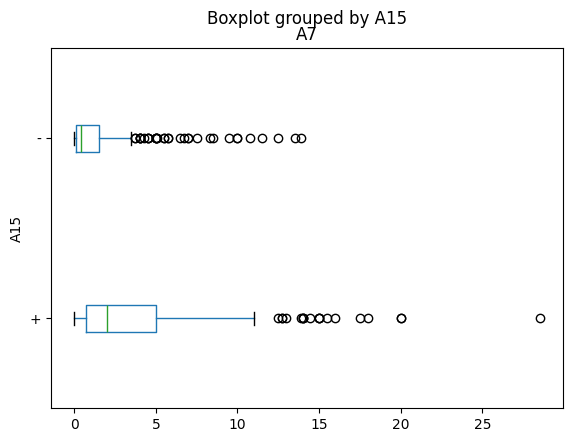

<Figure size 640x480 with 0 Axes>

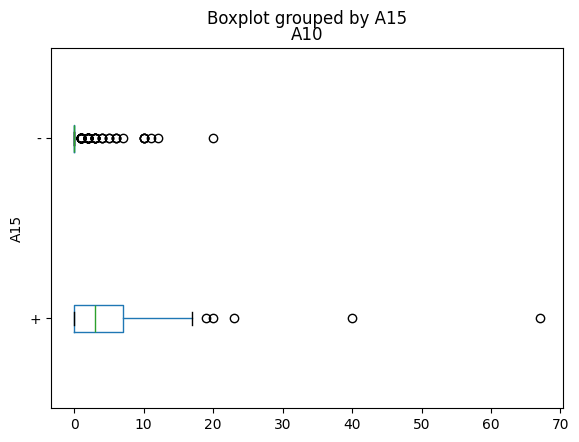

<Figure size 640x480 with 0 Axes>

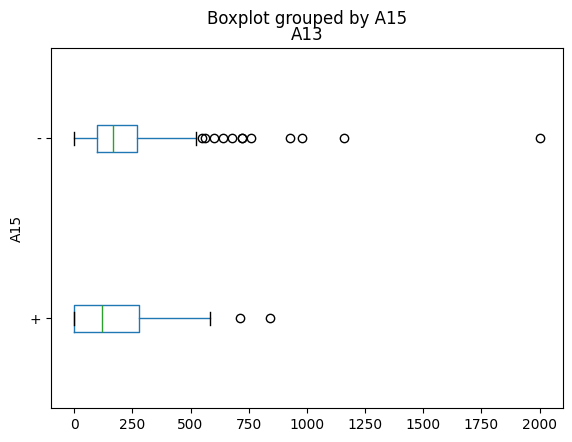

<Figure size 640x480 with 0 Axes>

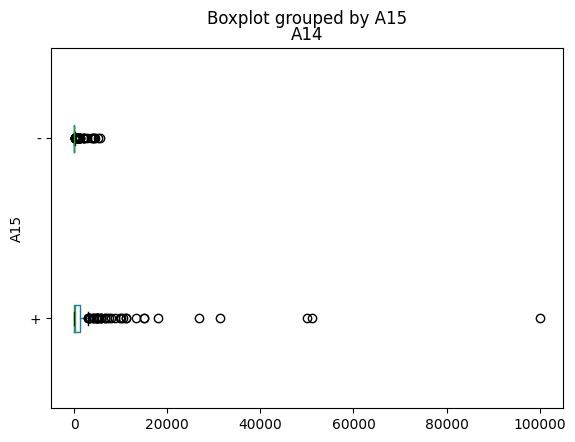

In [32]:
for var in num_vars:
    plt.figure()
    df.boxplot(column=var, by="A15", grid=False, vert=False)
    plt.show()

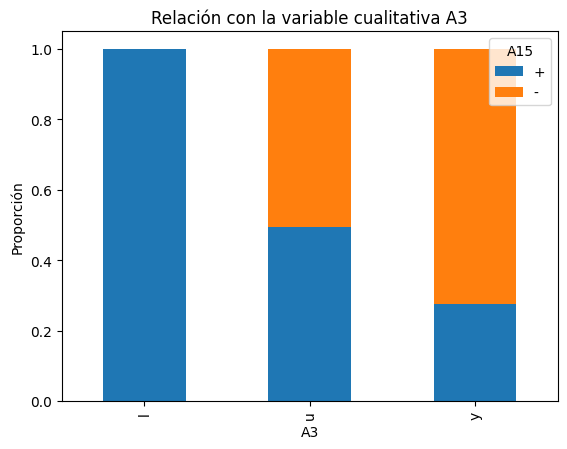

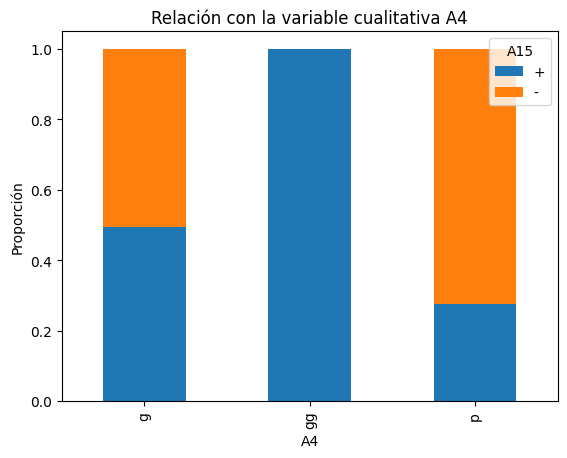

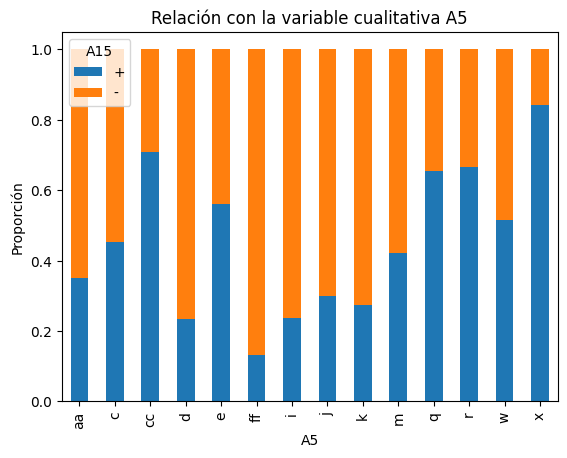

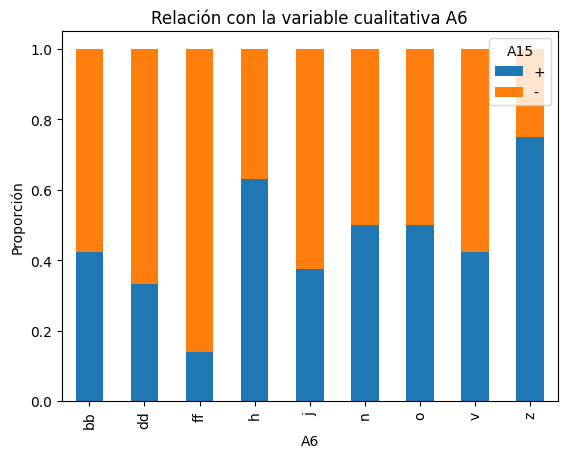

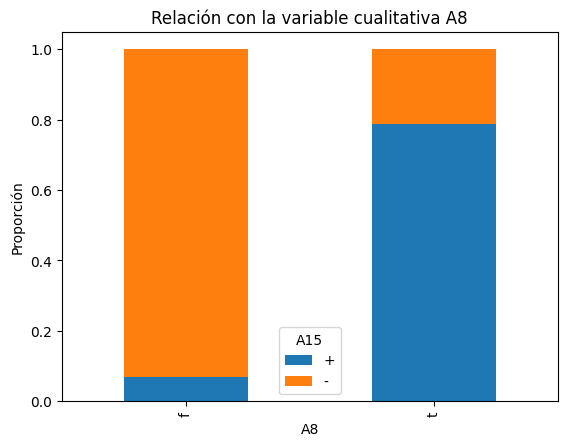

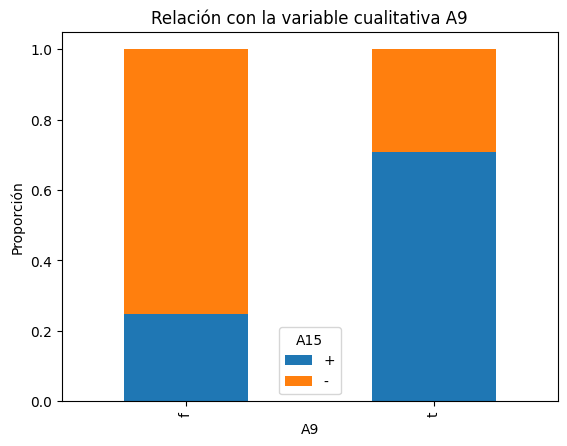

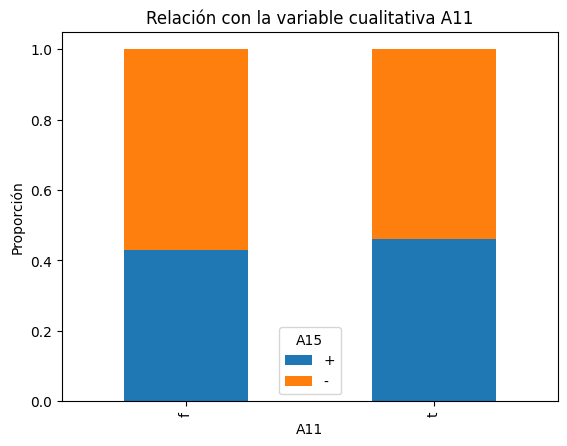

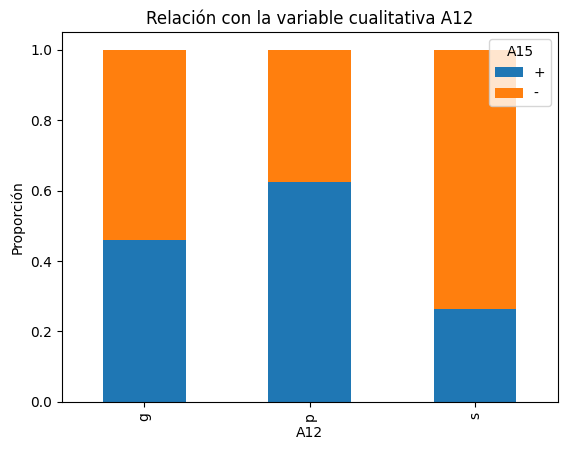

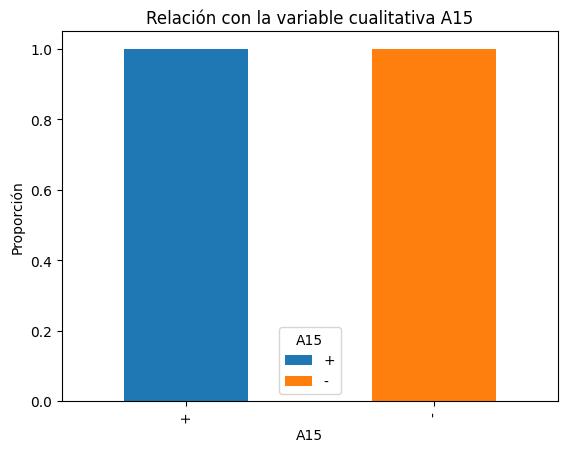

In [33]:
for var in cat_vars:
    tabla = pd.crosstab(df[var], df['A15'], normalize='index')
    tabla.plot.bar(stacked=True)
    plt.title(f'Relación con la variable cualitativa {var}')
    plt.ylabel('Proporción')
    plt.show()

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
  R// En esta relación en casi todas las variables cuantitativas se puede ver direncias notorias entre grupos, sobre todo en la variable A2, pero en la variable A14 NO se puede percibir ninguna diferencia

- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
  R// En general, las variables cualitativas analizadas presentan diferencias en la distribución de A15 dependiendo de sus categorías. Algunas categorías tienen una mayor proporción de +, mientras que otras presentan una mayor proporción de -

- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?
  R// Según lo visto en las gráficas de proporciones y en los diagramas de cajas se puede decir que casi todas las variables tienen una buena capacidad predictora, menos la variable cualitativa A14 y la variable cuantitativa A11, pues en estas no se puede percibir una diferencia nororia que nos permita mostrar una relación.